In [33]:
#importing required libraries
import pandas as pd
import numpy as np

In [34]:
df = pd.read_csv("dataset.csv")
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [35]:
#Basic Dataset Inspection
# Column names and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [36]:
# Missing values check
df.isnull().sum()

,0
title,0
rating,0
body,0


In [37]:
# Duplicate rows check
df.duplicated().sum()

np.int64(0)

In [38]:
#Creating Sentiment Labels from Rating
# Function to convert rating into sentiment category
def label_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

# Apply function to rating column
df['sentiment'] = df['rating'].apply(label_sentiment)

# Check sentiment distribution
print(df['sentiment'].value_counts())

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64


In [39]:
# Merge review title and body into one complete review
df['review'] = df['title'] + " " + df['body']

# Display sample merged review
print(df[['review', 'sentiment']].head())

                                              review sentiment
0  Horrible product Very disappointed with the ov...  Negative
1  Camera quality is not like 48 megapixel Camera...   Neutral
2  Overall Got the mobile on the launch date,Batt...  Positive
3  A big no from me 1. It doesn't work with 5.0GH...  Negative
4  Put your money somewhere else Not worth buying...  Negative


In [40]:
# nltk -> NLP preprocessing
import nltk


In [41]:
# Download WordNet
nltk.download('wordnet')

# Download additional multilingual/lemma support
nltk.download('omw-1.4')

# Download stopwords if not already downloaded
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [42]:
# re -> regular expressions for text cleaning
import re

# string -> punctuation removal
import string

# stopwords -> remove common words like 'the', 'is'
from nltk.corpus import stopwords

# WordNetLemmatizer -> convert words to root form
from nltk.stem import WordNetLemmatizer

In [43]:
#Text Cleaning Function
#Initialize stopwords
stop_words = set(stopwords.words('english'))

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Custom function for cleaning text
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Keep only alphabets
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization = split sentence into words
    words = text.split()

    # Remove stopwords + lemmatize words
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # Join cleaned words back
    return ' '.join(words)

In [44]:
# Create cleaned review column
df['cleaned_review'] = df['review'].apply(clean_text)

# Compare original vs cleaned
print(df[['review', 'cleaned_review']].head())

                                              review  \
0  Horrible product Very disappointed with the ov...   
1  Camera quality is not like 48 megapixel Camera...   
2  Overall Got the mobile on the launch date,Batt...   
3  A big no from me 1. It doesn't work with 5.0GH...   
4  Put your money somewhere else Not worth buying...   

                                      cleaned_review  
0  horrible product disappointed overall performa...  
1   camera quality like megapixel camera quality low  
2  overall got mobile launch datebattery must app...  
3  big doesnt work ghz wifi frequency ghz old sch...  
4  put money somewhere else worth buyingfaulty so...  


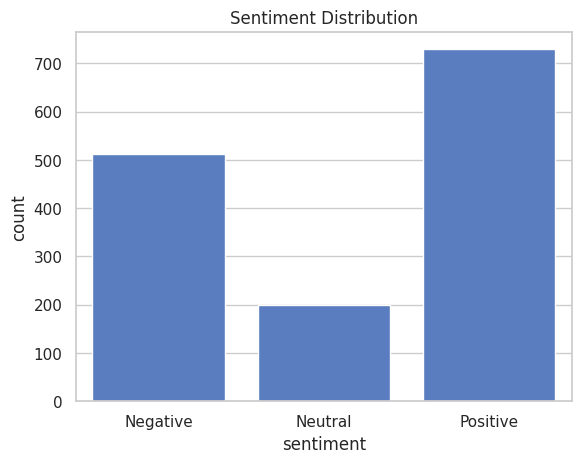

In [45]:
#Exploratory Data Analysis (EDA)
# matplotlib -> basic visualizations
import matplotlib.pyplot as plt

# seaborn -> advanced visualizations
import seaborn as sns

#Sentiment Distribution Plot
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [46]:
!pip install wordcloud

In [47]:
#Import WordCloud class
from wordcloud import WordCloud

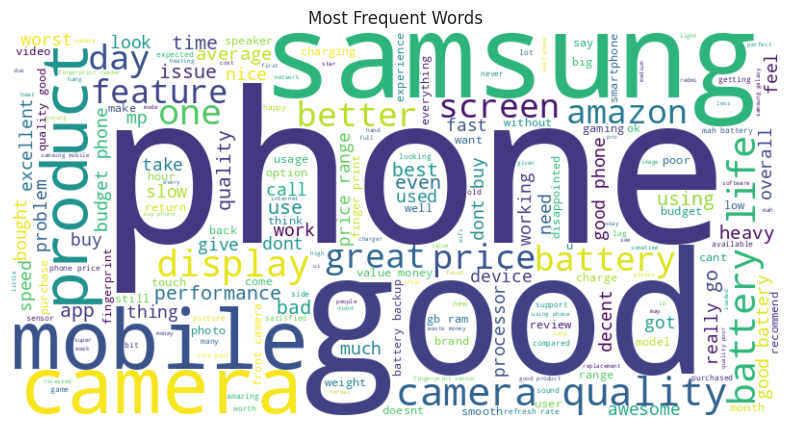

In [48]:
# Join all cleaned reviews
all_words = ' '.join(df['cleaned_review'])

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words")
plt.show()

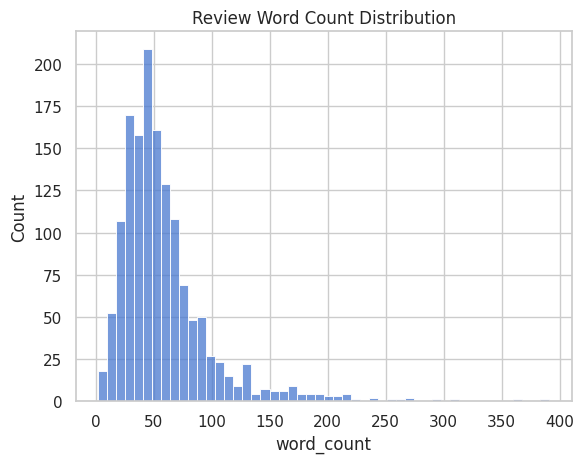

In [49]:
# Character count
df['char_count'] = df['review'].apply(len)

# Word count
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

sns.histplot(df['word_count'], bins=50)
plt.title("Review Word Count Distribution")
plt.show()

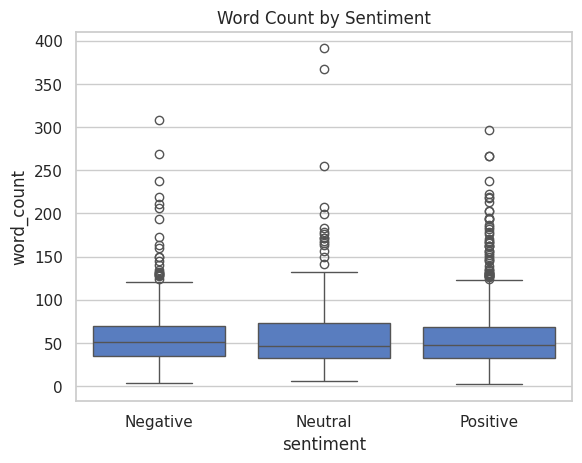

In [50]:
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title("Word Count by Sentiment")
plt.show()

#Model Buliding And Evaluation

In [51]:
# ─── Core ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ─── NLP ────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ─── Feature Engineering ────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── Preprocessing ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# ─── Models ─────────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.naive_bayes     import MultinomialNB
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier

# ─── Evaluation ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)

# ─── Visualisation ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ─── Persist Model ──────────────────────────────────────────────────────
import pickle

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


---
##  Feature Engineering — TF-IDF Vectorisation

In [52]:
# ──  TF-IDF (uni + bigrams) ──────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features  = 5000,
    ngram_range   = (1, 2),     # unigrams + bigrams
    sublinear_tf  = True,       # apply log normalisation
    min_df        = 2           # ignore very rare terms
)

X = tfidf.fit_transform(df['cleaned_review'])
y = df['sentiment']

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Classes       : {y.unique()}")

Feature Matrix Shape : (1440, 5000)
Target Classes       : ['Negative' 'Neutral' 'Positive']


---
## Train / Test Split

In [53]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_enc       # preserve class proportions
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing  Samples : {X_test.shape[0]}")

Training Samples : 1152
Testing  Samples : 288


In [54]:
# ──   Handle Class Imbalance with SMOTE (on train set only) ────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After  SMOTE:", dict(zip(*np.unique(y_train_res, return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(410), np.int64(1): np.int64(159), np.int64(2): np.int64(583)}
After  SMOTE: {np.int64(0): np.int64(583), np.int64(1): np.int64(583), np.int64(2): np.int64(583)}


---
##  Model Training

In [55]:
# ── Define Models ────────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes'         : MultinomialNB(alpha=0.5),
    'Linear SVM'          : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, random_state=42)
}

In [56]:
# ──   5-Fold Stratified Cross-Validation ───────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<22} | CV Acc: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression    | CV Acc: 0.9011 ± 0.0153
Naive Bayes            | CV Acc: 0.8719 ± 0.0059
Linear SVM             | CV Acc: 0.9085 ± 0.0157
Random Forest          | CV Acc: 0.8931 ± 0.0099
Gradient Boosting      | CV Acc: 0.8485 ± 0.0166


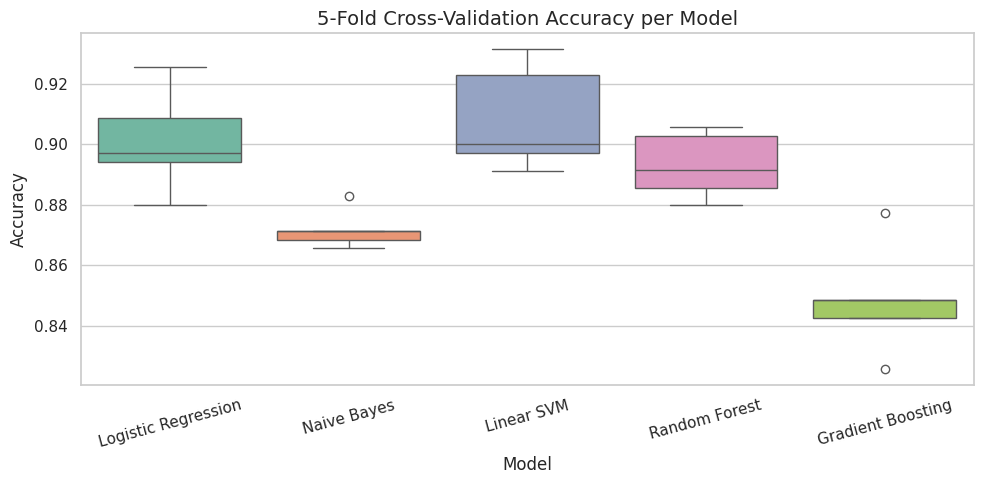

In [57]:
# ──   Visualise Cross-Validation Accuracy ─────────────────────────────
cv_df = pd.DataFrame(cv_results).melt(var_name='Model', value_name='Accuracy')

plt.figure(figsize=(10, 5))
sns.boxplot(data=cv_df, x='Model', y='Accuracy', palette='Set2')
plt.title('5-Fold Cross-Validation Accuracy per Model', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
##  Model Evaluation on Test Set

In [58]:
# ──  Fit all models on resampled train → evaluate on held-out test ────
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Test Accuracy': round(acc, 4)})
    trained_models[name] = (model, y_pred)
    print(f"{name:<22} | Test Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n", results_df)

Logistic Regression    | Test Accuracy: 0.7674
Naive Bayes            | Test Accuracy: 0.7535
Linear SVM             | Test Accuracy: 0.7708
Random Forest          | Test Accuracy: 0.7639
Gradient Boosting      | Test Accuracy: 0.7465

                  Model  Test Accuracy
2           Linear SVM         0.7708
0  Logistic Regression         0.7674
3        Random Forest         0.7639
1          Naive Bayes         0.7535
4    Gradient Boosting         0.7465


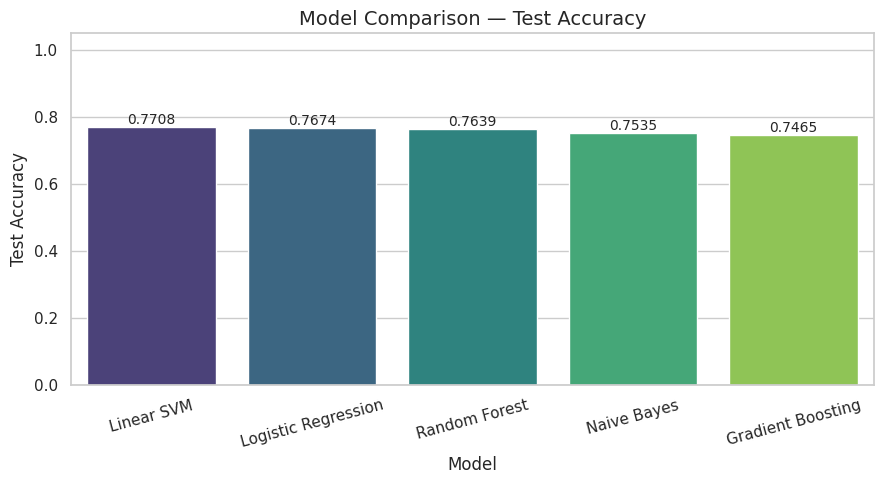

In [59]:
# ── Bar Chart — Test Accuracy Comparison ────────────────────────────
plt.figure(figsize=(9, 5))
bars = sns.barplot(
    data    = results_df,
    x       = 'Model',
    y       = 'Test Accuracy',
    palette = 'viridis'
)
for bar in bars.patches:
    bars.annotate(
        f"{bar.get_height():.4f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=10
    )
plt.title('Model Comparison — Test Accuracy', fontsize=14)
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [62]:
# ──  Classification Reports for ALL models ───────────────────────────
class_names = label_encoder.inverse_transform([0, 1, 2])

for name, (model, y_pred) in trained_models.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=class_names))

  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.77      0.84      0.81       102
     Neutral       0.44      0.28      0.34        40
    Positive       0.82      0.85      0.83       146

    accuracy                           0.77       288
   macro avg       0.68      0.66      0.66       288
weighted avg       0.75      0.77      0.75       288

  Naive Bayes
              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80       102
     Neutral       0.32      0.30      0.31        40
    Positive       0.83      0.84      0.84       146

    accuracy                           0.75       288
   macro avg       0.65      0.65      0.65       288
weighted avg       0.75      0.75      0.75       288

  Linear SVM
              precision    recall  f1-score   support

    Negative       0.75      0.86      0.80       102
     Neutral       0.44      0.20      0.28        40
    Positive       0.82   

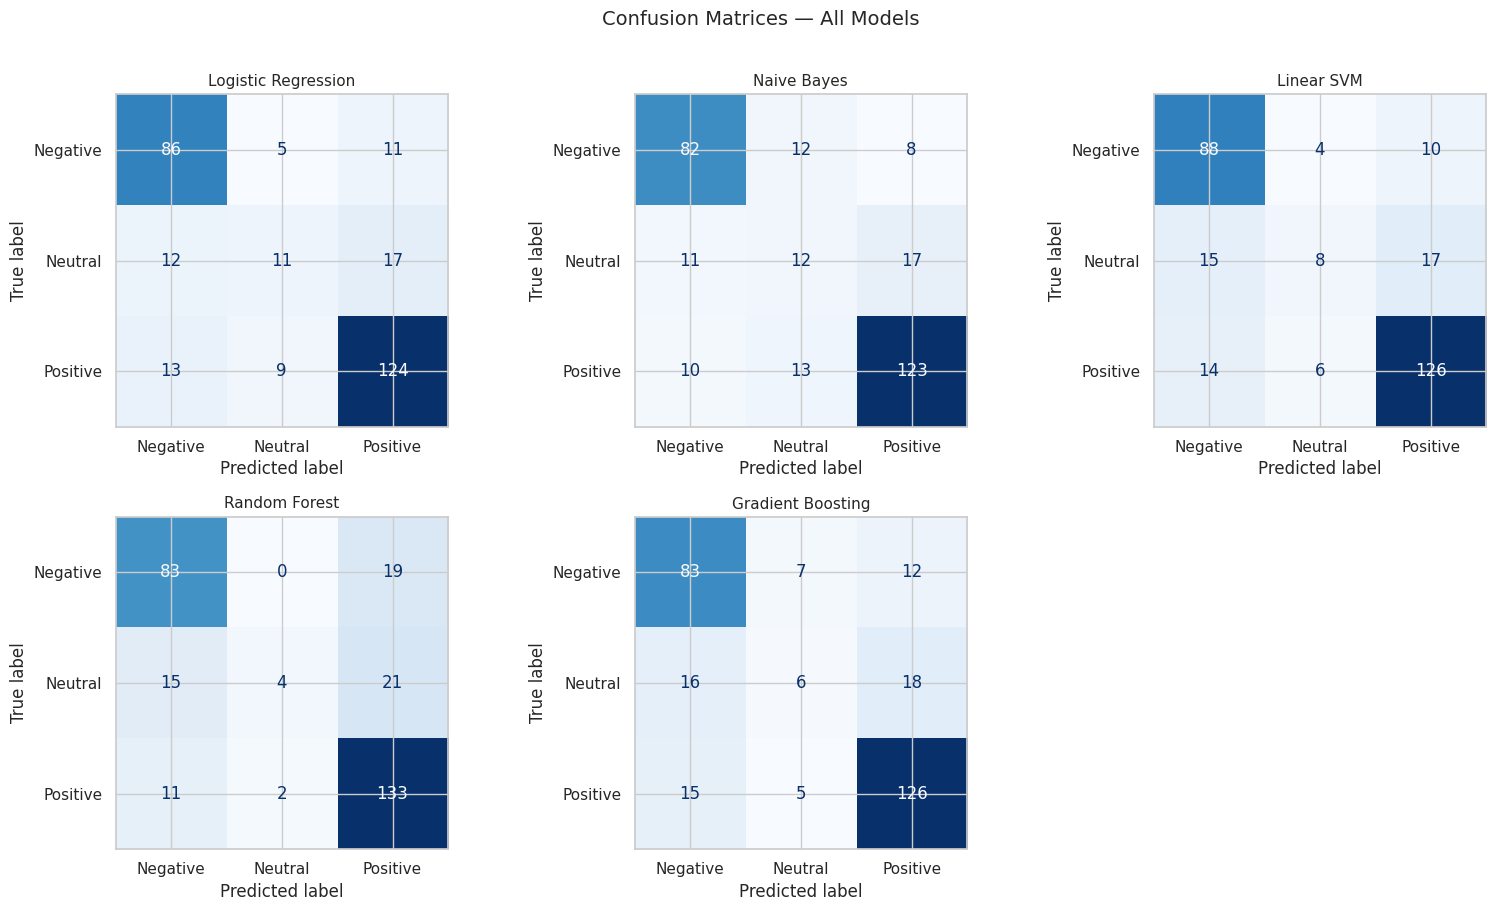

In [63]:
# ──  Confusion Matrices (side-by-side grid) ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, (model, y_pred)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=11)

# Hide unused subplot
if len(trained_models) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
##  Best Model — Deep Dive

In [82]:
# ──  Identify Best Model ──────────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_model, best_y_pred = trained_models[best_model_name]

print(f"🏆 Best Model : {best_model_name}")
print(f"   Test Acc   : {accuracy_score(y_test, best_y_pred):.4f}")

🏆 Best Model : Linear SVM
   Test Acc   : 0.7708


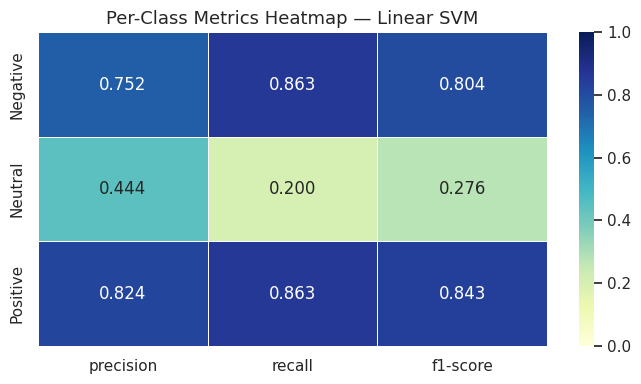

In [83]:
# ── Per-Class Precision / Recall / F1 Heat-Map ──────────────────────
report_dict = classification_report(
    y_test, best_y_pred,
    target_names = class_names,
    output_dict  = True
)
report_df = pd.DataFrame(report_dict).T.iloc[:-3, :3]  # drop support + avg rows

plt.figure(figsize=(7, 4))
sns.heatmap(
    report_df.astype(float),
    annot=True, fmt='.3f',
    cmap='YlGnBu', linewidths=0.5,
    vmin=0, vmax=1
)
plt.title(f'Per-Class Metrics Heatmap — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

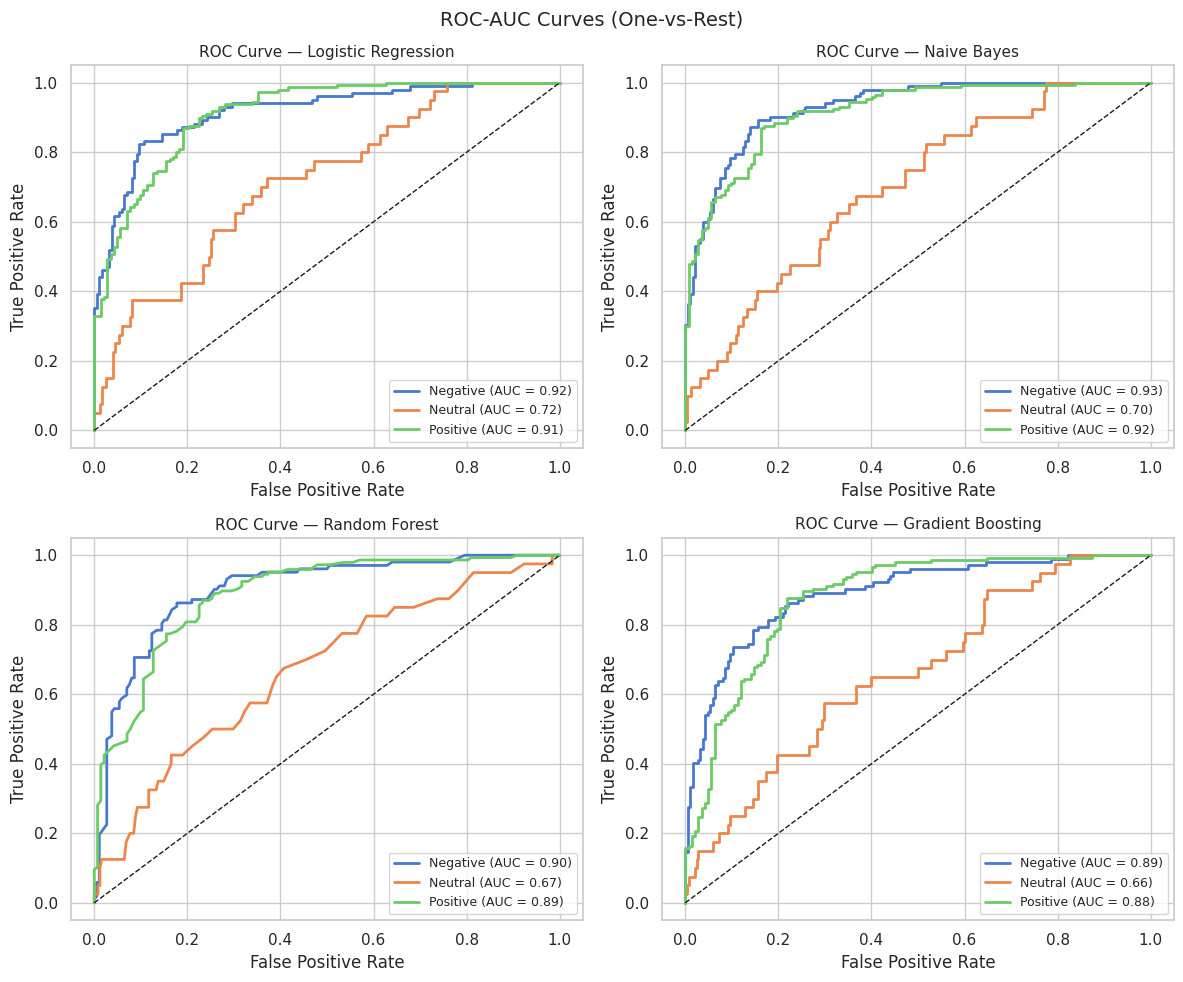

In [84]:
# ──   ROC-AUC (One-vs-Rest, only for models that support predict_proba) ─
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

proba_models = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'Gradient Boosting']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax_idx, m_name in enumerate(proba_models):
    model_obj = trained_models[m_name][0]
    y_score   = model_obj.predict_proba(X_test)

    for cls_idx, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_score[:, cls_idx])
        roc_auc      = auc(fpr, tpr)
        axes[ax_idx].plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    axes[ax_idx].plot([0,1],[0,1], 'k--', lw=1)
    axes[ax_idx].set_title(f'ROC Curve — {m_name}', fontsize=11)
    axes[ax_idx].set_xlabel('False Positive Rate')
    axes[ax_idx].set_ylabel('True Positive Rate')
    axes[ax_idx].legend(loc='lower right', fontsize=9)

plt.suptitle('ROC-AUC Curves (One-vs-Rest)', fontsize=14)
plt.tight_layout()
plt.show()

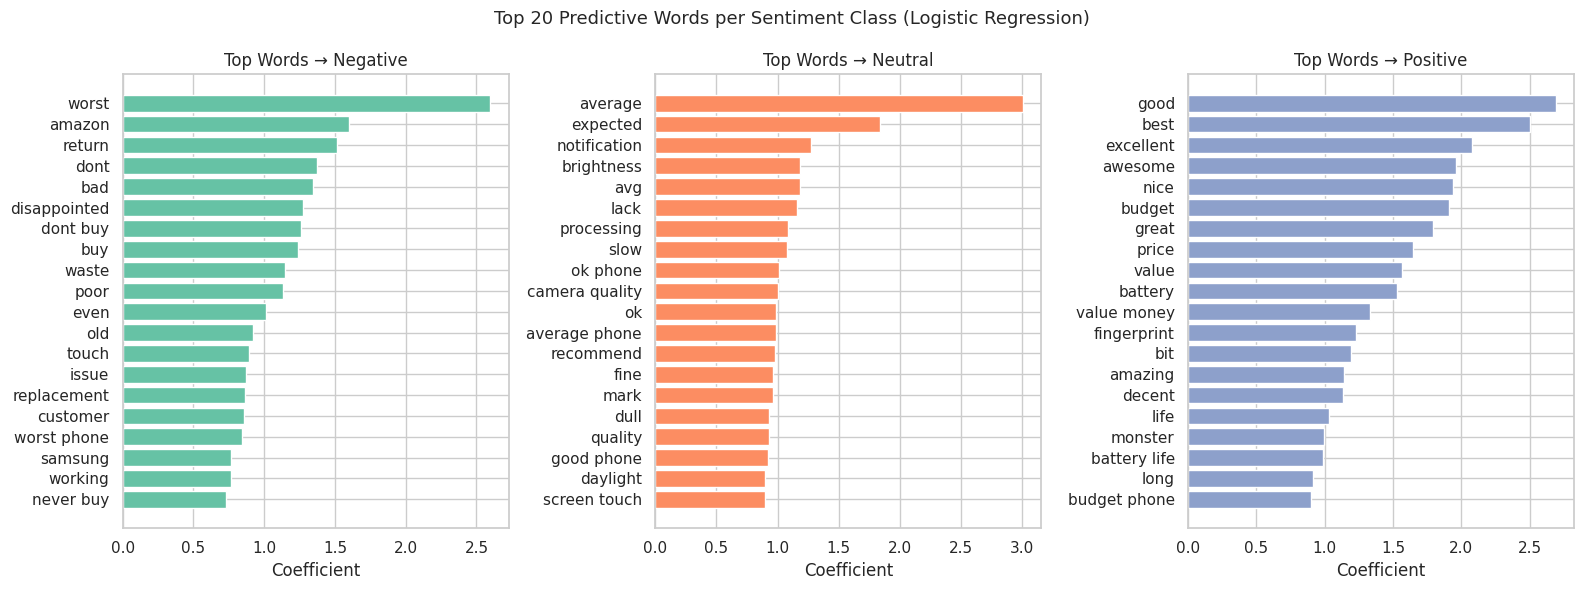

In [67]:
# ── Top-20 TF-IDF Features per Sentiment (Logistic Regression coefs) ─
lr_model = trained_models['Logistic Regression'][0]
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for i, class_label in enumerate(class_names):
    top_idx   = lr_model.coef_[i].argsort()[-20:][::-1]
    top_words = feature_names[top_idx]
    top_coefs = lr_model.coef_[i][top_idx]

    axes[i].barh(top_words[::-1], top_coefs[::-1], color=sns.color_palette('Set2')[i])
    axes[i].set_title(f'Top Words → {class_label}', fontsize=12)
    axes[i].set_xlabel('Coefficient')

plt.suptitle('Top 20 Predictive Words per Sentiment Class (Logistic Regression)', fontsize=13)
plt.tight_layout()
plt.show()

---
##  Model Comparison Summary

In [68]:
# ──   Full Summary Table (CV mean ± std + Test Accuracy) ──────────────
summary_rows = []
for name, (model, y_pred) in trained_models.items():
    cv_scores = cv_results[name]
    test_acc  = accuracy_score(y_test, y_pred)
    report    = classification_report(y_test, y_pred, output_dict=True)
    summary_rows.append({
        'Model'           : name,
        'CV Mean Acc'     : round(cv_scores.mean(), 4),
        'CV Std'          : round(cv_scores.std(),  4),
        'Test Accuracy'   : round(test_acc, 4),
        'Macro F1'        : round(report['macro avg']['f1-score'], 4),
        'Weighted F1'     : round(report['weighted avg']['f1-score'], 4)
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Test Accuracy', ascending=False)
summary_df.reset_index(drop=True, inplace=True)
print(summary_df.to_string(index=False))

              Model  CV Mean Acc  CV Std  Test Accuracy  Macro F1  Weighted F1
         Linear SVM       0.9085  0.0157         0.7708    0.6408       0.7502
Logistic Regression       0.9011  0.0153         0.7674    0.6594       0.7549
      Random Forest       0.8931  0.0099         0.7639    0.5982       0.7255
        Naive Bayes       0.8719  0.0059         0.7535    0.6495       0.7508
  Gradient Boosting       0.8485  0.0166         0.7465    0.6033       0.7239


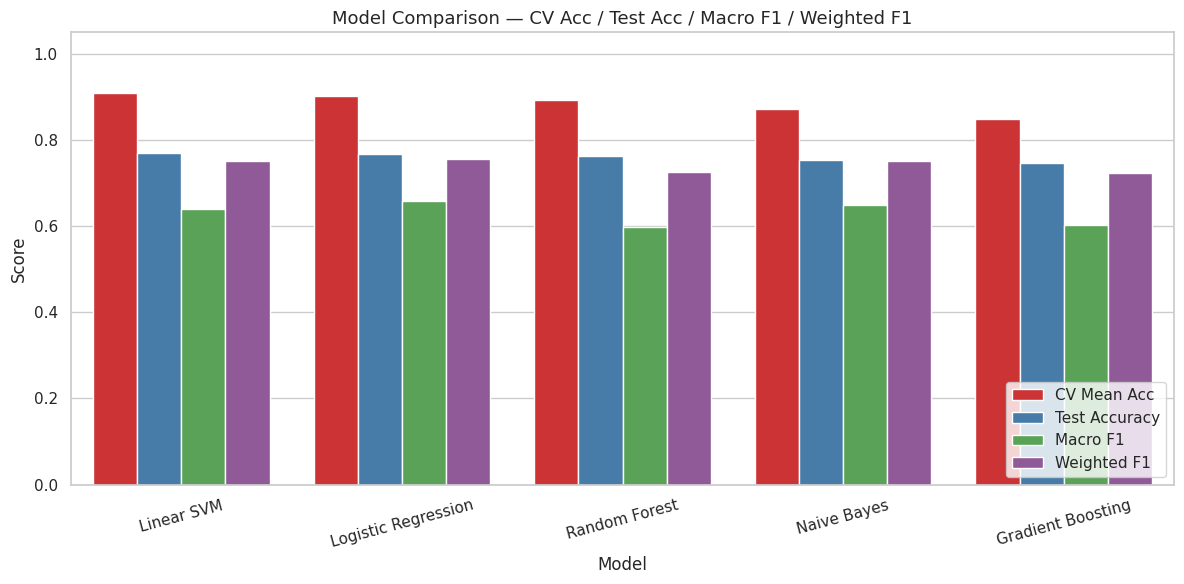

In [69]:
# ── Multi-Metric Bar Chart ───────────────────────────────────────────
plot_df = summary_df.melt(
    id_vars   = 'Model',
    value_vars = ['CV Mean Acc', 'Test Accuracy', 'Macro F1', 'Weighted F1'],
    var_name  = 'Metric',
    value_name = 'Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='Set1')
plt.title('Model Comparison — CV Acc / Test Acc / Macro F1 / Weighted F1', fontsize=13)
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
##  Save Best Model

In [80]:
# ──  Pickle best model + TF-IDF vectoriser + Label encoder ───────────
artifacts = {
    'model'      : best_model,
    'vectorizer' : tfidf,
    'label_enc'  : label_encoder
}

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print(f"✅ Saved model  : sentiment_model.pkl")
print(f"   Best model   : {best_model_name}")
print(f"   Test Accuracy: {accuracy_score(y_test, best_y_pred):.4f}")

✅ Saved model  : sentiment_model.pkl
   Best model   : Linear SVM
   Test Accuracy: 0.7708


---
## Inference — Predict on New Reviews

In [81]:
# ──   Load saved model and predict on custom reviews ─────────────────
with open('sentiment_model.pkl', 'rb') as f:
    saved = pickle.load(f)

new_reviews = [
    "Absolutely love this product! Works perfectly and battery lasts all day.",
    "Average product. Not great, not terrible. Does the job I suppose.",
    "Waste of money. Broke within a week. Poor quality and terrible customer service."
]

cleaned_new  = [clean_text(r) for r in new_reviews]
X_new        = saved['vectorizer'].transform(cleaned_new)
y_new_enc    = saved['model'].predict(X_new)
y_new_labels = saved['label_enc'].inverse_transform(y_new_enc)

for review, label in zip(new_reviews, y_new_labels):
    print(f"Review   : {review[:70]}...")
    print(f"Predicted: {label}")
    print("-" * 75)

Review   : Absolutely love this product! Works perfectly and battery lasts all da...
Predicted: Positive
---------------------------------------------------------------------------
Review   : Average product. Not great, not terrible. Does the job I suppose....
Predicted: Neutral
---------------------------------------------------------------------------
Review   : Waste of money. Broke within a week. Poor quality and terrible custome...
Predicted: Negative
---------------------------------------------------------------------------
